# PREPOCESSING DATA

## Tahap 1: Load Dataset

### Import Library

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

### Baca Dataset

In [53]:
df = pd.read_csv('dataset_tugas1_preprocessing.csv')
print(df.head())

      ID  Nama Jenis_Kelamin            Prodi Status Nilai_Akhir  \
0  MH001  Iwan     Laki-laki  Teknik Komputer  Aktif         NaN   
1  MH002   Eka     Perempuan  Teknik Komputer  Lulus           E   
2  MH003  Iwan     Laki-laki  Teknik Komputer  Aktif         NaN   
3  MH004   Eka     Perempuan  Teknik Komputer  Aktif           D   
4  MH005  Joko     Perempuan     Data Science  Aktif           C   

  Tanggal_Ujian  Umur  
0    13-04-2020   NaN  
1    2020/12/11  28.0  
2    2021/11/21  23.0  
3    2021/08/19  18.0  
4    2020/01/05  26.0  


## Tahap 2: Eksplorasi Awal (EDA)

### Struktur dan Tipe Data 

In [54]:
print("Shape:", df.shape)
print("\nTipe Data:")
print(df.dtypes)

Shape: (99, 8)

Tipe Data:
ID                   str
Nama                 str
Jenis_Kelamin        str
Prodi                str
Status               str
Nilai_Akhir          str
Tanggal_Ujian        str
Umur             float64
dtype: object


### Jumlah Nilai Hilang Per Kolom

In [55]:
print("Jumlah Missing Values:")
print(df.isnull().sum())

Jumlah Missing Values:
ID                0
Nama              0
Jenis_Kelamin     0
Prodi             0
Status            0
Nilai_Akhir      29
Tanggal_Ujian     0
Umur              9
dtype: int64


### Statistik Deskriptif

In [56]:
print("Statistik Deskriptif:")
df.describe(include='all')

Statistik Deskriptif:


,ID,Nama,Jenis_Kelamin,Prodi,Status,Nilai_Akhir,Tanggal_Ujian,Umur
count,99,99,99,99,99,70,99,90.000000
unique,99,10,2,4,4,5,97,NaN
top,MH001,Eka,Laki-laki,Teknik Komputer,Cuti,C,2020/03/31,NaN
freq,1,15,50,28,29,17,2,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.366667
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.763963
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26.000000


## Tahap 3: Menangani Missing Values

In [57]:
# Nilai Akhir >> Isi Dengan Modus (Karena Kategorikal)
mode_nilai = df['Nilai_Akhir'].mode()[0]
print("\nCheck Modus Nilai Akhir")
print("Modus Nilai Akhir: ",mode_nilai)

df['Nilai_Akhir'] = df['Nilai_Akhir'].fillna(mode_nilai)

print("\nSetelah Isi Nilai Akhir")
print(df[['Nilai_Akhir']].head())
print("Sisa Null:", df['Nilai_Akhir'].isnull().sum())

# Umur >> Isi Dengan Median (Karena Numerikal)
median_umur = df['Umur'].median()
print("\nCheck Median Umur")
print("Median Umur:", median_umur)

df['Umur'] = df['Umur'].fillna(median_umur)

print("\nSetelah Isi Umur")
print(df[['Umur']].head())
print("Sisa Null:", df['Umur'].isnull().sum())

print("\nSetelah Semua Imputasi")
print(df.isnull().sum())
print(df.head())


Check Modus Nilai Akhir
Modus Nilai Akhir:  C

Setelah Isi Nilai Akhir
  Nilai_Akhir
0           C
1           E
2           C
3           D
4           C
Sisa Null: 0

Check Median Umur
Median Umur: 23.0

Setelah Isi Umur
   Umur
0  23.0
1  28.0
2  23.0
3  18.0
4  26.0
Sisa Null: 0

Setelah Semua Imputasi
ID               0
Nama             0
Jenis_Kelamin    0
Prodi            0
Status           0
Nilai_Akhir      0
Tanggal_Ujian    0
Umur             0
dtype: int64
      ID  Nama Jenis_Kelamin            Prodi Status Nilai_Akhir  \
0  MH001  Iwan     Laki-laki  Teknik Komputer  Aktif           C   
1  MH002   Eka     Perempuan  Teknik Komputer  Lulus           E   
2  MH003  Iwan     Laki-laki  Teknik Komputer  Aktif           C   
3  MH004   Eka     Perempuan  Teknik Komputer  Aktif           D   
4  MH005  Joko     Perempuan     Data Science  Aktif           C   

  Tanggal_Ujian  Umur  
0    13-04-2020  23.0  
1    2020/12/11  28.0  
2    2021/11/21  23.0  
3    2021/08/19  18.0

## Tahap 4: Normalisasi Format Tanggal

In [58]:
print("Contoh nilai Tanggal_Ujian:")
print(df['Tanggal_Ujian'].dropna().unique()[:20])

def parse_tanggal(tgl):
    for fmt in ('%d-%m-%Y', '%Y/%m/%d'):
        try:
            return pd.to_datetime(tgl, format=fmt)
        except ValueError:
            pass
    return pd.NaT

df['Tanggal_Ujian'] = df['Tanggal_Ujian'].apply(parse_tanggal)

print("\nParsing Tanggal_Ujian")
print("Tipe kolom Tanggal_Ujian:", df['Tanggal_Ujian'].dtype)
print(df['Tanggal_Ujian'].head(10))

print("\nCek Gagal Parsing Tanggal_Ujian")
print("Jumlah NaT:", df['Tanggal_Ujian'].isnull().sum())

print("\nData Gagal Parsing:")
print(df[df['Tanggal_Ujian'].isnull()].head())

Contoh nilai Tanggal_Ujian:
<StringArray>
['13-04-2020', '2020/12/11', '2021/11/21', '2021/08/19', '2020/01/05',
 '2021/10/15', '2020/01/15', '2020/09/16', '2021/02/06', '2020/02/12',
 '10-10-2020', '2022/12/02', '2021/02/19', '2020/06/17', '2022/04/22',
 '2020/02/11', '2022/12/31', '2020/11/06', '2020/09/19', '2022/12/10']
Length: 20, dtype: str

Parsing Tanggal_Ujian
Tipe kolom Tanggal_Ujian: datetime64[us]
0   2020-04-13
1   2020-12-11
2   2021-11-21
3   2021-08-19
4   2020-01-05
5   2021-10-15
6   2020-01-15
7   2020-09-16
8   2021-02-06
9   2020-02-12
Name: Tanggal_Ujian, dtype: datetime64[us]

Cek Gagal Parsing Tanggal_Ujian
Jumlah NaT: 0

Data Gagal Parsing:
Empty DataFrame
Columns: [ID, Nama, Jenis_Kelamin, Prodi, Status, Nilai_Akhir, Tanggal_Ujian, Umur]
Index: []


## Tahap 5: Encoding Label

In [59]:
le = LabelEncoder()

kolom_kategorikal = ['Nama', 'Jenis_Kelamin', 'Prodi', 'Status', 'Nilai_Akhir']

for kolom in kolom_kategorikal:
    df[kolom] = le.fit_transform(df[kolom].astype(str))

print("Encoding selesai!")
print(df.head())

Encoding selesai!
      ID  Nama  Jenis_Kelamin  Prodi  Status  Nilai_Akhir Tanggal_Ujian  Umur
0  MH001     8              0      3       0            2    2020-04-13  23.0
1  MH002     4              1      3       3            4    2020-12-11  28.0
2  MH003     8              0      3       0            2    2021-11-21  23.0
3  MH004     4              1      3       0            3    2021-08-19  18.0
4  MH005     9              1      0       0            2    2020-01-05  26.0


## Tahap 6: Split Data

In [60]:
X = df.drop(columns=['Status'])
y = df['Status']

print("Split Fitur dan Target")
print("Shape x (Fitur)  :", X.shape)
print("Shape y (Target) :", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTrain Test Split")
print(f"Data Latih x    : {X_train.shape}")
print(f"Data Uji y      : {X_test.shape}")
print(f"Data Latih y    : {y_train.shape}")
print(f"Data Uji y      : {y_test.shape}")

print("\nJumlah Baris")
print(f"Data Latih      : {X_train.shape[0]} baris")
print(f"Data Uji        : {X_test.shape[0]} baris")

Split Fitur dan Target
Shape x (Fitur)  : (99, 7)
Shape y (Target) : (99,)

Train Test Split
Data Latih x    : (79, 7)
Data Uji y      : (20, 7)
Data Latih y    : (79,)
Data Uji y      : (20,)

Jumlah Baris
Data Latih      : 79 baris
Data Uji        : 20 baris


## Tahap 7: Visualisasi

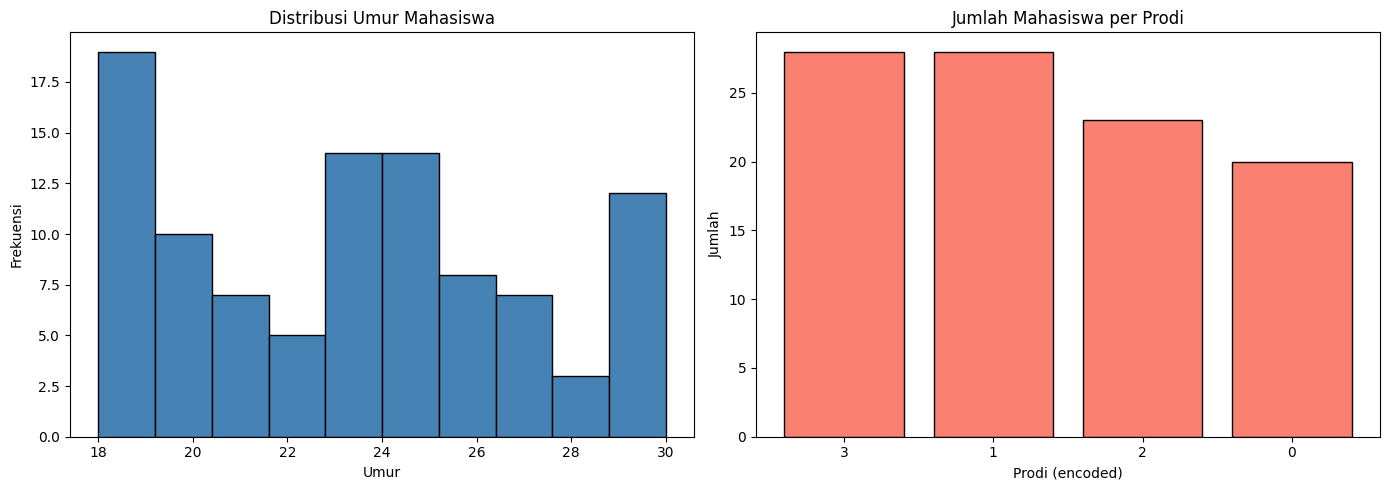

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram Umur
axes[0].hist(df['Umur'], bins=10, color='steelblue', edgecolor='black')
axes[0].set_title('Distribusi Umur Mahasiswa')
axes[0].set_xlabel('Umur')
axes[0].set_ylabel('Frekuensi')

# Bar chart Prodi
prodi_count = df['Prodi'].value_counts()
axes[1].bar(prodi_count.index.astype(str), prodi_count.values, color='salmon', edgecolor='black')
axes[1].set_title('Jumlah Mahasiswa per Prodi')
axes[1].set_xlabel('Prodi (encoded)')
axes[1].set_ylabel('Jumlah')

plt.tight_layout()
plt.savefig('visualisasi_tugas1.png', dpi=150)
plt.show()